### 프로젝트 과정
1. 전체 corpus를 전처리한다.(최대 단어 길이로 제한: 40개, 불용어 제거)
2. Mecab(형태소 분류기)를 사용해 vocab을 만들어 문장을 토큰 단위로 embedding을 한다. Embedding
3. seq2seqwithattention 모델을 사용하여 모델 학습을 완료한다.
4. 모델 성능 확인하기
    - train acc, train loss 그래프 확인하기
    - Model test(예시 문장으로 실제 번역을 해보고 attention map 출력하기)

### 문제점
- 정량적 평가를 위해 어떤 지표를 도입해야 하는가?
    1. Train Accuracy & Loss
    - 모델이 학습 데이터에 얼마나 잘 적응하고 있는지를 보여주는 실시간 성적표입니다.
        - Train Accuracy (학습 정확도): 모델이 학습 데이터의 정답을 얼마나 맞혔는지를 0에서 1사이(또는 0~100\%)로 나타냅니다.
            - 의미: 모델이 학습 데이터를 '암기'하거나 '이해'하는 능력입니다.
            - 최적 지향점: $1.0$ ($100\%$)에 점진적으로 도달하는 것을 목표로 합니다. 다만, 검증 데이터와의 간극이 벌어질 경우 과적합(Overfitting) 상태를 시사합니다.
        - Loss Graph (손실 그래프): 모델의 예측값과 실제 정답 사이의 오차(Error)를 나타냅니다.
            - 의미: 학습이 진행됨에 따라 오차가 줄어들고 있는지를 확인하는 지표입니다.
            - 수렴 판정 기준: 낮을수록 좋습니다. 그래프가 매끄럽게 하향 곡선을 그리며 수렴하는 형태가 가장 이상적입니다.
    2. BLEU Score (Bilingual Evaluation Understudy)
    - 기계가 생성한 문장이 사람이 작성한 참조(Reference) 문장과 얼마나 유사한지 단어(N-gram)의 겹침을 바탕으로 계산합니다.
        - 의미: 단어의 선택과 순서가 얼마나 일치하는지를 측정하는 '형태적 유사도' 지표입니다.
        - 수치 해석: $0$에서 $1$ 사이(주로 $0$~$100$으로 표기)의 값을 가집니다.
            - $0.4(40)$ 이상: 매우 우수하고 이해하기 쉬운 번역/생성 수준.
            - $0.2 \sim 0.3$: 일반적인 기계 번역 모델의 준수한 성적.
        - 성능 임계치: 높을수록 좋습니다. 하지만 단어의 '의미'보다는 '철자'가 일치해야 점수가 올라가는 한계가 있습니다.

    3. BERTScore
    - 사전 학습된 BERT 모델의 임베딩(Embedding)을 사용하여 두 문장 사이의 문맥적 유사도를 계산합니다.
        - 의미: 단순한 단어 일치 여부를 넘어, 단어의 '의미'와 '맥락'이 얼마나 비슷한지를 측정하는 '심층적 유사도' 지표입니다.
        - 장점: "차가운"과 "차디찬"처럼 단어는 다르지만 의미가 같은 경우, BLEU는 점수를 깎지만 BERTScore는 높은 점수를 줍니다.
        - 유효 역역: 높을수록(1에 가까울수록) 좋습니다. 일반적으로 0.8 \sim 0.9 이상의 점수가 나오면 문맥적으로 매우 유사하다고 판단합니다.

- 정성적 평가를 위해 어떤 지표를 도입해야 하는가?
    - 번역 적절성 및 충실도(Adequacy & Fidelity):  
        - 판단 방법: 한국어 원문의 **핵심 명사(키워드)**가 영어 예측 문장에 포함되어 있는지 확인합니다.

        - 판단 사례: 원문의 '시민'이 예측 문장의 'citizens'로, '새로운'이 'new'로 매칭되었다면 비록 전체 문장이 어색하더라도 번역의 적절성이 일부 확보된 것으로 봅니다.

    - 도메인 적합성 및 환각 체크(Domain Sensitivity & Hallucination):   
        - 판단 방법: 원문에는 없는 **뉴스 특화 단어(대통령, CNN, AP 등)**가 예측 문장에 갑자기 등장하는지 체크합니다.

        - 판단 사례: '양말'이나 '영화'를 주제로 한 일상적 원문을 모델이 '정부(government)'나 '방송(today show)' 관련 문장으로 치환하여 생성한다면, 이는 학습 데이터 도메인(뉴스)에 강하게 편향된 것으로 판단합니다.

    - 어텐션 정렬 분석(Attention Alignment Analysis):   
        - 판단 방법: 시각화된 Attention Map에서 가로축(Source)과 세로축(Target) 사이의 대각선 패턴 형성 여부를 확인합니다.

        - 판단 사례: 특정 영어 단어를 생성하는 시점에 해당 단어와 의미적으로 연결된 한국어 단어 위치의 '에너지(밝기)'가 가장 높게 나타난다면 모델이 문맥을 올바르게 참조하고 있는 것으로 판단합니다.
### 결과  
[정량적 평가 기준]
- 모델이 학습 데이터에 대해 안정적인 최적화를 달성했음에도 불구하고, BLEU 및 BERTScore 평가에서 낮은 수치를 기록했습니다. 이는 학습 지표와 평가(evaluation) 지표 간의 불일치를 나타내며, 결과적으로 실제 모델의 성능 뿐만 아니라 일반화 성능도 기대에 미치지 못할 것으로 판단됩니다. 

[정성적 평가 기준]
- 양방향 어텐션 메커니즘을 통해 핵심 키워드 간의 정렬(Alignment)을 성공적으로 구현하여 모델의 구조적 타당성을 입증했으나, 뉴스 코퍼스에 편향된 학습 데이터의 한계로 인해 일상어와 신조어를 정치·사회 뉴스로 오해하여 번역하는 강력한 도메인 편향성과 환각 현상이 확인됩니다.

[최종결론]
- 데이터, 모델, 최적화, 평가 과정을 거치며 구조적 설계와 학습 최적화는 성공적이었으나, 데이터 편향에 따른 과대적합 문제로 인해 모델의 실제 성능 및 일반화 능력이 기대치에 미치지 못하는 것으로 결론지었습니다.(일반화 성능 포함)

### 회고
이번 교육 과정에서 번역 모델을 만든 게 2번째인 거 같은데 왜 새로 하는 느낌인지 모르겠다... 지난번은 모델의 성능을 높이기 위해 다양한 방법을 사용한 거에 비해(최적화) 이번엔 평가에 집중해서 그런 건가? 어렵다...

In [1]:
# !sudo apt update
# !sudo apt-get install -y fonts-nanum
# !pip install sentencepiece
# !pip install bert-score nltk

### 라이브러리 임포트 및 디바이스 설정

In [2]:
# 1. 라이브러리 및 환경 설정
import os
import re
import json
import numpy as np
from tqdm import tqdm

from konlpy.tag import Mecab
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# 평가용 라이브러리
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from bert_score import score

# 한글 폰트 설정
fontpath = "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"
if os.path.exists(fontpath):
    fontprop = fm.FontProperties(fname=fontpath, size=12) 
    plt.rcParams["font.family"] = fontprop.get_name()

In [3]:
# 하이퍼 파라미터
VOCAB_SIZE = 30000 
MIN_LEN = 0
MAX_LEN = 40 
RATIO = 2.5

EPOCH = 30
BATCH_SIZE = 32
EMB_DIM = 256
HID_DIM = 512

# 토크나이저 설정
tokenizer = Mecab()

# 디바이스 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# 경로 설정
dataset_dir = os.path.expanduser("./datasets")


Device: cuda


### 데이터 다운로드

In [4]:
# # 2. 데이터 다운로드
# import urllib.request
# import tarfile

# os.makedirs(dataset_dir, exist_ok=True)
# tar_path = os.path.join(dataset_dir, "korean-english-park.train.tar.gz")

# if not os.path.exists(tar_path):
#     print("데이터 다운로드 중...")
#     url = "https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz"
#     urllib.request.urlretrieve(url, tar_path)
#     print("다운로드 완료!")

# if not os.path.exists(os.path.join(dataset_dir, "korean-english-park.train.ko")):
#     with tarfile.open(tar_path, 'r:gz') as tar_ref:
#         tar_ref.extractall(dataset_dir)

### 데이터 정제

In [5]:
path_to_ko = os.path.join(dataset_dir, "korean-english-park.train.ko")
path_to_en = os.path.join(dataset_dir, "korean-english-park.train.en")

In [6]:
# 1. 한국어 전처리 (정규식)
def preprocess_sentence_ko(sentence):
    sentence = sentence.strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z가-힣ㄱ-ㅎㅏ-ㅣ?.!,]+", " ", sentence)
    return sentence.strip()

# 2. 영어 전처리 (정규식 + 태그 추가)
def preprocess_sentence_en(sentence):
    sentence = sentence.lower().strip()
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
    sentence = sentence.strip()
    return f"<start> {sentence} <end>"

# 3. 통계 계산 및 출력 함수
def calculate_lengths(ko_lengths, en_lengths, min_l, max_l):
    ko_arr, en_arr = np.array(ko_lengths), np.array(en_lengths)
    ko_median, en_median = np.median(ko_arr), np.median(en_arr)
    
    ko_coverage = np.sum((ko_arr >= min_l) & (ko_arr <= max_l)) / len(ko_arr) * 100
    en_coverage = np.sum((en_arr >= min_l) & (en_arr <= max_l)) / len(en_arr) * 100

    print(f"\n--- [토큰화 데이터 기준] 통계 정보 ---")
    print(f"전체 데이터 수: {len(ko_lengths)}")
    print(f"중앙값: 한국어({ko_median:.1f}), 영어({en_median:.1f})")
    print(f"설정 구간({min_l}~{max_l}) 포함 비율: KO({ko_coverage:.2f}%), EN({en_coverage:.2f}%)")
    return ko_median, en_median

# 4. 시각화 함수
def visualize_lengths(ko_lengths, en_lengths, ko_median, en_median, min_l, max_l):
    plt.figure(figsize=(12, 5))
    # 한국어 분포
    plt.subplot(1, 2, 1)
    plt.hist(ko_lengths, bins=50, color='blue', alpha=0.6)
    plt.axvline(ko_median, color='red', linestyle='--', label=f'Median: {ko_median}')
    plt.axvline(min_l, color='purple', linestyle='--', label=f'MIN: {min_l}')
    plt.axvline(max_l, color='green', linestyle='--', label=f'MAX: {max_l}')
    plt.title('Korean Token Length Distribution')
    plt.legend()

    # 영어 분포
    plt.subplot(1, 2, 2)
    plt.hist(en_lengths, bins=50, color='orange', alpha=0.6)
    plt.axvline(en_median, color='red', linestyle='--', label=f'Median: {en_median}')
    plt.axvline(min_l, color='purple', linestyle='--', label=f'MIN: {min_l}')
    plt.axvline(max_l, color='green', linestyle='--', label=f'MAX: {max_l}')
    plt.title('English Token Length Distribution')
    plt.legend()
    plt.tight_layout()
    plt.show()

Tokenizing All Data: 100%|██████████| 78968/78968 [00:11<00:00, 7127.68it/s] 



--- [토큰화 데이터 기준] 통계 정보 ---
전체 데이터 수: 78968
중앙값: 한국어(28.0), 영어(26.0)
설정 구간(0~40) 포함 비율: KO(84.17%), EN(88.95%)


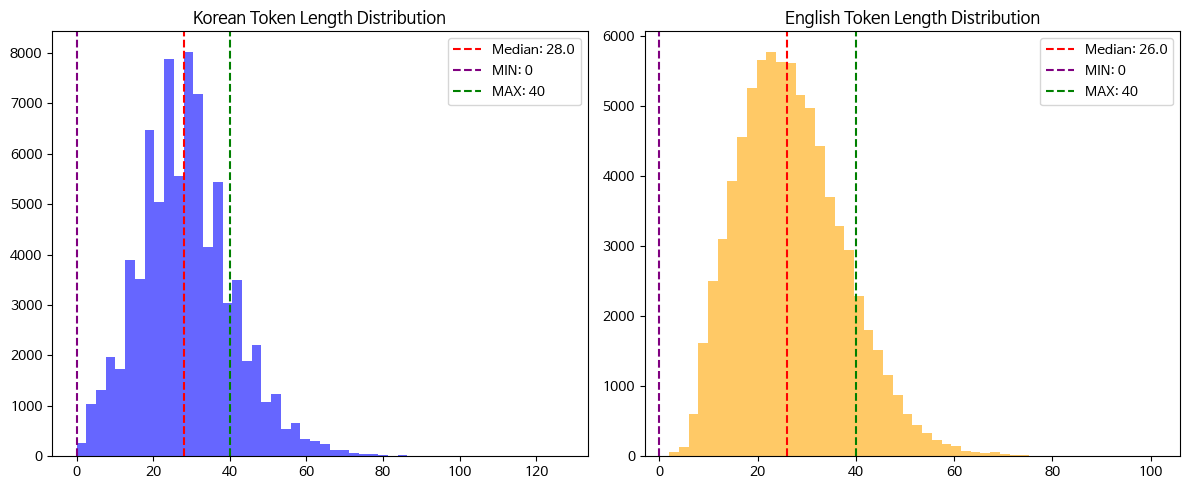


최종 필터링 완료! 남은 데이터 수: 61023


In [7]:
# 1단계: 데이터 로드 및 중복 제거
with open(path_to_ko, "r", encoding="utf-8") as f: raw_ko = f.read().splitlines()
with open(path_to_en, "r", encoding="utf-8") as f: raw_en = f.read().splitlines()
cleaned_corpus = list(set(zip(raw_ko, raw_en))) # 중복 제거

# # 전체 코드 디버깅용
# cleaned_corpus = cleaned_corpus[:1000]

# 2단계: 전체 데이터 토큰화 수행 (필터링 전)
tokenized_ko_all = []
tokenized_en_all = []

for ko, en in tqdm(cleaned_corpus, desc="Tokenizing All Data"):
    # 각각의 방식으로 전처리 및 토큰화 진행
    ko_tokens = tokenizer.morphs(preprocess_sentence_ko(ko))
    en_tokens = preprocess_sentence_en(en).split()
    
    tokenized_ko_all.append(ko_tokens)
    tokenized_en_all.append(en_tokens)

# 3단계: 토큰화된 상태의 분포 확인
ko_lens = [len(t) for t in tokenized_ko_all]
en_lens = [len(t) for t in tokenized_en_all]

ko_med, en_med = calculate_lengths(ko_lens, en_lens, MIN_LEN, MAX_LEN)
visualize_lengths(ko_lens, en_lens, ko_med, en_med, MIN_LEN, MAX_LEN)

# 4단계: 정밀 필터링 (길이 + 비율 기준)
kor_corpus, eng_corpus = [], []

for ko, en in zip(tokenized_ko_all, tokenized_en_all):
    l_ko = len(ko)
    l_en = len(en)
    
    # 1. 길이 조건 체크 
    if not (MIN_LEN <= l_ko <= MAX_LEN): continue
    if not (MIN_LEN <= l_en <= MAX_LEN): continue
    
    # 2. 비율 조건 체크
    if l_ko == 0 or l_en == 0:
        continue 
    
    # 3. 비율 계산 
    len_ratio = max(l_ko, l_en) / min(l_ko, l_en)
    
    if len_ratio > RATIO: 
        continue
    
    kor_corpus.append(ko)
    eng_corpus.append(en)

print(f"\n최종 필터링 완료! 남은 데이터 수: {len(kor_corpus)}")

### 토큰화 및 데이터로더 구축

In [8]:
# 4. 토큰화 (Step 3) 및 데이터로더
class CustomVocab:
    def __init__(self, corpus=None, vocab_size=10000):
        self.pad_id = 0
        self.bos_id = 1
        self.eos_id = 2
        self.unk_id = 3
        
        self.word2idx = {"<pad>": 0, "<start>": 1, "<end>": 2, "<unk>": 3}
        self.idx2word = {0: "<pad>", 1: "<start>", 2: "<end>", 3: "<unk>"}
        
        # corpus가 주어졌을 때만 단어장을 구축하도록 설정 (불러올 때 에러 방지)
        if corpus is not None:
            words = [word for tokens in corpus for word in tokens]
            word_counts = Counter(words)
            
            # 특수 토큰이 랭킹을 덮어쓰는 것 방지
            for token in ["<pad>", "<start>", "<end>", "<unk>"]:
                if token in word_counts:
                    del word_counts[token]
                    
            vocab_words = [word for word, count in word_counts.most_common(vocab_size - 4)]
            
            for idx, word in enumerate(vocab_words, start=4):
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                
    def encode(self, tokens):
        return [self.word2idx.get(w, self.unk_id) for w in tokens]
    
    def __len__(self):
        return len(self.word2idx)

    def save(self, file_path):
        """어휘 사전을 JSON 파일로 저장합니다."""
        with open(file_path, 'w', encoding='utf-8') as f:
            json.dump({
                'word2idx': self.word2idx, 
                'idx2word': self.idx2word
            }, f, ensure_ascii=False, indent=4)
            
    @classmethod
    def load(cls, file_path):
        """JSON 파일로부터 CustomVocab 객체를 복원하여 반환합니다."""
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            
        # 데이터 구축용 corpus 없이 빈 단어장 객체 생성
        vocab = cls(corpus=None) 

        vocab.word2idx = data['word2idx']
        vocab.idx2word = {int(k): v for k, v in data['idx2word'].items()}
        
        return vocab

In [9]:
# 단어장 크기 최소 10,000 이상
ko_vocab = CustomVocab(kor_corpus, vocab_size=VOCAB_SIZE)
en_vocab = CustomVocab(eng_corpus, vocab_size=VOCAB_SIZE)

ko_vocab.save('ko_vocab.json')
en_vocab.save('en_vocab.json')

class NMTDataset(Dataset):
    def __init__(self, src_corpus, trg_corpus, src_vocab, trg_vocab, max_len=40):
        self.src_corpus = src_corpus
        self.trg_corpus = trg_corpus
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.src_corpus)

    def __getitem__(self, idx):
        src_ids = self.src_vocab.encode(self.src_corpus[idx])[:self.max_len]
        trg_ids = self.trg_vocab.encode(self.trg_corpus[idx])[:self.max_len]

        trg_input = trg_ids[:-1]
        trg_label = trg_ids[1:]

        src_ids += [self.src_vocab.pad_id] * (self.max_len - len(src_ids))
        trg_input += [self.trg_vocab.pad_id] * (self.max_len - len(trg_input))
        trg_label += [self.trg_vocab.pad_id] * (self.max_len - len(trg_label))

        return torch.tensor(src_ids), torch.tensor(trg_input), torch.tensor(trg_label)
    
train_data = NMTDataset(kor_corpus, eng_corpus, ko_vocab, en_vocab, max_len=MAX_LEN)
# 훈련 데이터와 검증 데이터 분리하지 않음
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

### 모델 설계

In [10]:
# 5. 모델 설계 (Step 4)
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim)
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # (batch_size, src_len, hidden_dim)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # (batch_size, src_len, hidden_dim)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch_size, src_len, hidden_dim)
        attention = self.v(energy).squeeze(2)  # (batch_size, src_len)

        return nn.functional.softmax(attention, dim=1)  # (batch_size, src_len)

In [11]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src):
        # src : (src_len, batch_size)
        embedded = self.embedding(src)  # embedded : (src_len, batch_size, emb_dim)
        outputs, hidden = self.rnn(embedded)  # outputs : (src_len, batch_size, hidden_dim)

        return outputs, hidden

In [12]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention):
        super(Decoder, self).__init__()

        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        # Decoder RNN에는 embedding만 입력
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층에는 hidden state와 attention value가 결합되어 입력
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)

    def forward(self, input, hidden, encoder_outputs):
        # input : (batch_size,)
        # hidden : (batch_size, hidden_dim)
        # encoder_outputs : (src_len, batch_size, hidden_dim)
        input = input.unsqueeze(0)  # input : (1, batch_size)
        embedded = self.embedding(input)  # embedded : (1, batch_size, emb_dim)

        # attention distribution을 계산합니다. decoder의 이전 hidden state, s_{t-1}와 encoder의 H가 입력됩니다.
        a = self.attention(hidden[-1], encoder_outputs)  # a : (batch_size, src_len)

        # H에 가중치를 부여해 attention value(Context vector) 계산
        a = a.unsqueeze(1)  # a : (batch_size, 1, src_len)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)  # encoder_outputs : (batch_size, src_len, hidden_dim)
        context = torch.bmm(a, encoder_outputs)  # context : (batch_size, 1, hidden_dim)
        context = context.permute(1, 0, 2)  # context : (1, batch_size, hidden_dim)

        output, hidden = self.rnn(embedded, hidden)

        # 출력층에서는 현재 hidden state와 context vector를 결합하여 예측값 생성
        output = output.squeeze(0)  # output : (batch_size, hidden_dim)
        context = context.squeeze(0)  # context : (batch_size, hidden_dim)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch_size, output_dim)

        return prediction, hidden, a.squeeze(1)

In [13]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=30, bos_id = 1, eos_id=2):
        # 학습 모드에서는 trg_len 사용, 추론 모드에서는 max_len까지 동적 생성
        batch_size = src.shape[1]
        trg_vocab_size = self.decoder.fc_out.out_features

        # 조기 종료를 위해 tensor가 아닌 리스트 사용
        outputs = []

        # 시각화를 위해 attention 저장
        attentions = []

        # 인코더를 통해 context 생성
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            for t in range(0, trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))

        else:
		    # inference에서는 target(정답)이 없기 때문에 sos_token을 생성해줍니다.
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden,  encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료 조건
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)  # (trg_len, batch_size, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch_size, src_len)

        return outputs, attentions

In [14]:
encoder = Encoder(len(ko_vocab), EMB_DIM, HID_DIM).to(device)
attention = BahdanauAttention(HID_DIM).to(device)
decoder = Decoder(len(en_vocab), EMB_DIM, HID_DIM, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

### 훈련하기

In [15]:
# 7. 훈련 로직
def train_model(model, train_loader, criterion, epochs, device, save_dir="./checkpoints"):
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCH,  eta_min=1e-5)
    # 저장할 디렉토리가 없으면 자동 생성
    os.makedirs(save_dir, exist_ok=True)
    
    history = {'train_loss': [], 'train_acc': []}
    pad_id = 0 

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        epoch_acc = 0 
        
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
        
        for src, trg_input, trg_label in progress_bar:
            src = src.permute(1, 0).to(device)
            trg_input = trg_input.permute(1, 0).to(device)
            trg_label = trg_label.permute(1, 0).to(device)
            
            optimizer.zero_grad()
            outputs, _ = model(src, trg=trg_input)
            
            outputs = outputs.reshape(-1, outputs.shape[-1])
            trg_label = trg_label.reshape(-1)

            loss = criterion(outputs, trg_label)
            loss.backward()

            # [정확도 계산]
            preds = outputs.argmax(dim=-1)
            non_pad_mask = (trg_label != pad_id)
            correct = ((preds == trg_label) & non_pad_mask).sum().item()
            total = non_pad_mask.sum().item()
            
            batch_acc = correct / total if total > 0 else 0
            epoch_acc += batch_acc

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
            optimizer.step()

            epoch_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item(), acc=batch_acc)
            
        # 에포크 종료 후 스케줄러 업데이트
        scheduler.step()

        avg_train_loss = epoch_loss / len(train_loader)
        avg_train_acc = epoch_acc / len(train_loader)
        
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)

        if (epoch + 1) % 10 == 0 or (epoch+1) == epochs:
            save_path = os.path.join(save_dir, f"seq2seq_model_epoch_{epoch+1}.pt")
            torch.save(model.state_dict(), save_path)
            progress_bar.write(f"[Checkpoint] Epoch {epoch+1} 모델이 저장되었습니다: {save_path}")

    return history

In [16]:
criterion = nn.CrossEntropyLoss(ignore_index=ko_vocab.pad_id, label_smoothing=0.1)

In [17]:
history = train_model(model, train_loader, criterion, epochs=EPOCH, device=device, save_dir= f"./checkpoints_ED{EMB_DIM}_HD{HID_DIM}")

Epoch 10/30: 100%|██████████| 1907/1907 [08:19<00:00,  3.82it/s, acc=0.747, loss=2.5] 


[Checkpoint] Epoch 10 모델이 저장되었습니다: ./checkpoints_ED256_HD512/seq2seq_model_epoch_10.pt


Epoch 20/30: 100%|██████████| 1907/1907 [08:19<00:00,  3.82it/s, acc=0.994, loss=1.61]


[Checkpoint] Epoch 20 모델이 저장되었습니다: ./checkpoints_ED256_HD512/seq2seq_model_epoch_20.pt


Epoch 30/30: 100%|██████████| 1907/1907 [08:20<00:00,  3.81it/s, acc=0.998, loss=1.47]


[Checkpoint] Epoch 30 모델이 저장되었습니다: ./checkpoints_ED256_HD512/seq2seq_model_epoch_30.pt


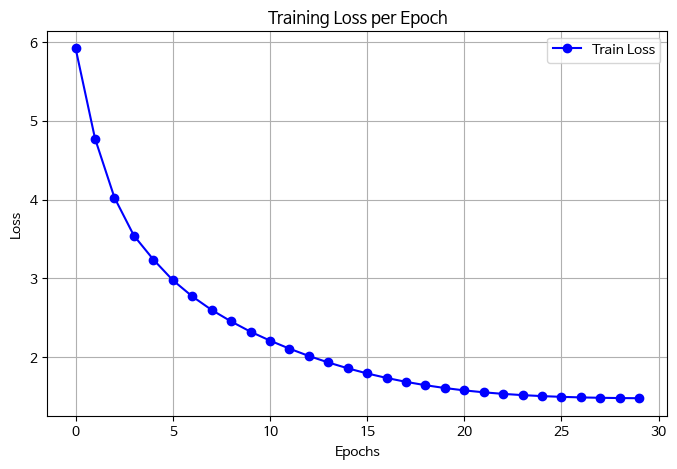

In [18]:
# Loss 그래프
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='o')
plt.title('Training Loss per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

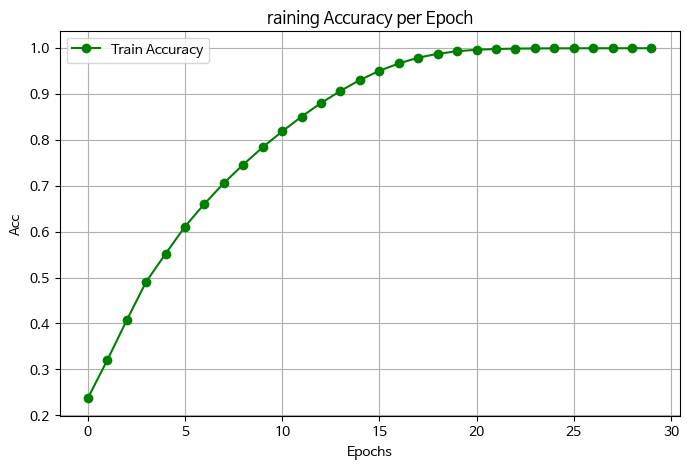

In [19]:
# Accuracy 그래프
plt.figure(figsize=(8, 5))
plt.plot(history['train_acc'], label='Train Accuracy', color='green', marker='o')
plt.title('raining Accuracy per Epoch')
plt.xlabel('Epochs')
plt.ylabel('Acc')
plt.grid(True)
plt.legend()
plt.show()

### 최종 번역 task

In [24]:
# 6. 번역 및 시각화 함수
def translate_sentence(sentence, model, src_vocab, trg_spm, max_len=40):
    model.eval()
    
    # 1. 한국어 전처리 및 토큰화
    sentence = preprocess_sentence_ko(sentence)
    tokens = tokenizer.morphs(sentence)
    
    # 2. 한국어 인코딩 (CustomVocab)
    src_ids = src_vocab.encode(tokens)[:max_len]
    src_ids += [src_vocab.pad_id] * (max_len - len(src_ids))
    src_tensor = torch.tensor(src_ids).unsqueeze(1).to(device)
    
    # 3. 모델 추론
    with torch.no_grad():
        # bos_id(1), eos_id(2)는 SPM 학습 시 설정한 값과 일치해야 합니다.
        outputs, attentions = model(src_tensor, max_len=max_len, bos_id=1, eos_id=2)
    
    # 4. 영어 디코딩 (SentencePiece)
    # 결과 ID 리스트 생성
    result_ids = [token.item() for token in outputs.argmax(2).squeeze(1)]
    
    # SPM의 decode_ids 메서드로 한 번에 문장으로 변환합니다.
    translation = trg_spm.decode_ids(result_ids)
        
    return translation, tokens, attentions.squeeze(1).cpu().numpy()

def analyze_translation_errors(candidates, references):
    """
    번역 결과와 정답을 비교하여 누락(Omission) 및 환각(Hallucination) 후보 단어를 분석합니다.
    """
    analysis_results = []
    
    for i, (cand, ref) in enumerate(zip(candidates, references)):
        cand_set = set(cand.lower().split())
        ref_set = set(ref.lower().split())
        
        # 1. 누락 후보 (정답에는 있으나 예측에는 없는 단어)
        omissions = list(ref_set - cand_set)
        
        # 2. 환각/오역 후보 (예측에는 있으나 정답에는 없는 단어)
        hallucinations = list(cand_set - ref_set)
        
        # 3. 단어 수준 일치율 (단순 참고용)
        intersection = cand_set.intersection(ref_set)
        word_recall = len(intersection) / len(ref_set) if len(ref_set) > 0 else 0
        
        analysis_results.append({
            'index': i,
            'omissions': omissions,
            'hallucinations': hallucinations,
            'recall': word_recall
        })
        
    return analysis_results

def print_error_report(test_pairs, candidates, references, analysis_results):
    """
    분석 결과를 리포트 형식으로 출력합니다.
    """
    print("\n" + "="*50)
    print("      번역 오류 분석 리포트 (Error Analysis)")
    print("="*50)
    
    for i, result in enumerate(analysis_results):
        ko_original = test_pairs[i][0]
        ref_text = references[i]
        pred_text = candidates[i]
        
        print(f"\n[문장 {i+1}]")
        print(f"  - 원문(KO): {ko_original}")
        print(f"  - 예측(EN): {pred_text}")
        print(f"  - 정답(EN): {ref_text}")
        
        if result['omissions']:
            print(f"  - 누락(Omission) 의심: {result['omissions']}")
        if result['hallucinations']:
            print(f"  -환각(Hallucination) 의심: {result['hallucinations']}")
            
        print(f"  - 단어 일치도: {result['recall']*100:.1f}%")
        print("-" * 30)

def plot_attention(attention, sentence_tokens, predicted_tokens):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.matshow(attention, cmap='viridis')
    fontdict = {'fontsize': 12}
    ax.set_xticks(range(len(sentence_tokens)))
    ax.set_xticklabels(sentence_tokens, fontdict=fontdict, rotation=90)
    ax.set_yticks(range(len(predicted_tokens)))
    ax.set_yticklabels(predicted_tokens, fontdict=fontdict)
    plt.show()

In [ ]:
# 1. 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. 어휘 사전(Vocabulary) 불러오기
ko_vocab = CustomVocab.load("ko_vocab.json")
en_vocab = CustomVocab.load('en_vocab.json')

# 3. 모델 구조 초기화
# 하이퍼파라미터는 학습 시와 정확히 일치해야 합니다.
encoder = Encoder(len(ko_vocab), EMB_DIM, HID_DIM).to(device)
attention = BahdanauAttention(HID_DIM).to(device)
decoder = Decoder(len(en_vocab), EMB_DIM, HID_DIM, attention).to(device)
model = Seq2SeqAttention(encoder, decoder, device).to(device)


In [33]:
test_pairs = [
    ("시민들은 거리로 나와 시위를 벌였습니다.", "citizens took to the streets to protest ."),
    ("나는 오늘 친구와 학식을 같이 먹었다.", "i ate school meals with my friend today ."),
    ("지금 매우 졸리고 힘들기 때문에 잠을 자야겠다.", "i need to sleep because i am very sleepy and tired now ."),
    ("한국의 대통령은 누구입니까?", "who is the president of south korea ?"),
    ("그 영화는 정말 감동적이었습니다.", "the movie was really touching .")
]

### epoch 20

In [ ]:
# 4. 학습된 모델 가중치 불러오기
save_dir= f"./checkpoints_ED{EMB_DIM}_HD{HID_DIM}"
model.load_state_dict(torch.load(f'{save_dir}/seq2seq_model_epoch_20.pt', map_location=device))

# 5. 모델 평가 모드 전환
# Dropout이나 BatchNorm 등을 추론 모드로 변경합니다.
model.eval()

In [65]:
candidates = []
references = []

print("--- 번역 결과 생성 중 ---")
for ko, en in test_pairs:
    pred, _, _ = translate_sentence(ko, model, ko_vocab, en_vocab)
    # 토큰화된 결과에서 <start>, <end> 등 불필요한 태그 정리
    pred_clean = pred.replace("<start>", "").replace("<end>", "").strip()
    
    candidates.append(pred_clean)
    references.append(en)
    print(f"원문: {ko}\n예측: {pred_clean}\n정답: {en}\n")

--- 번역 결과 생성 중 ---
원문: 시민들은 거리로 나와 시위를 벌였습니다.
예측: citizens in the street protests have been largely blamed for street protests .
정답: citizens took to the streets to protest .

원문: 나는 오늘 친구와 학식을 같이 먹었다.
예측: i m eating , i m eating , and i m up points .
정답: i ate school meals with my friend today .

원문: 지금 매우 졸리고 힘들기 때문에 잠을 자야겠다.
예측: now , it s hard not so easy to be .
정답: i need to sleep because i am very sleepy and tired now .

원문: 한국의 대통령은 누구입니까?
예측: korea s the military ?
정답: who is the president of south korea ?

원문: 그 영화는 정말 감동적이었습니다.
예측: it s a really hard film .
정답: the movie was really touching .



[파파고 기준]  
예측1: 거리 시위에 참여한 시민들은 주로 거리 시위의 원인으로 지목되어 왔습니다.(○)   
예측2: 저는 먹고 있어요, 먹고 있어요, 그리고 포인트를 올립니다.(△)  
예측3: 이제, 그렇게 쉽지 않은 일입니다.(X)  
예측4: 한국은 군대입니까?(X)  
예측5: 정말 어려운 영화입니다.(X)   

[gemini 직역]  
예측1: 거리 시위 중인 시민들은 거리 시위에 대해 크게 비난받아 왔습니다.    
예측2: 나는 먹고 있고, 먹고 있고, 그리고 나는 점수가 올라가고 있습니다.      
예측3: 지금은, (존재하기가) 그렇게 쉽지 않고 힘듭니다.     
예측4: 한국의 군대입니까?     
예측5: 그것은 정말 (이해하기) 어려운 영화입니다.   

### 정량적 평가

In [40]:
# 1. BLEU Score 측정
smoothie = SmoothingFunction().method4
bleu_scores = []
for cand, ref in zip(candidates, references):
    score_b = sentence_bleu([ref.split()], cand.split(), smoothing_function=smoothie)
    bleu_scores.append(score_b)

print(f"\n[정량적 평가 결과]")
print(f"평균 BLEU Score: {np.mean(bleu_scores):.4f}")


[정량적 평가 결과]
평균 BLEU Score: 0.0281


In [41]:
# 2. BERTScore 측정 (GPU VRAM 여유가 있을 때 실행)
try:
    print("\nBERTScore 계산 중 (잠시만 기다려주세요)...")
    P, R, F1 = score(candidates, references, lang="ko", verbose=False)
    print(f"평균 BERTScore (F1): {F1.mean().item():.4f}")
except Exception as e:
    print(f"BERTScore 계산 실패 (VRAM 부족 등): {e}")


BERTScore 계산 중 (잠시만 기다려주세요)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


평균 BERTScore (F1): 0.7482


### 정성적 평가

Input: 시민들은 거리로 나와 시위를 벌였습니다.
Predicted translation: citizens in the street protests have been largely blamed for street protests .


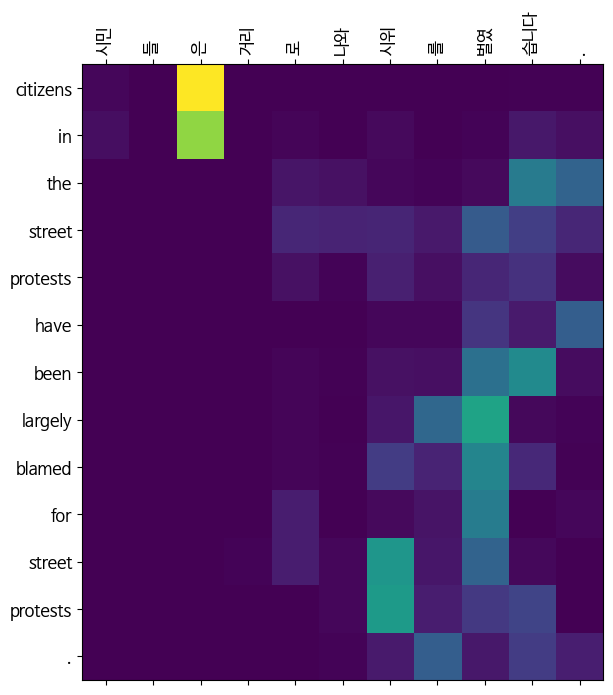

In [42]:
# 대표 문장 1개에 대해 심층 정성적 평가 진행
translation, tokens, attention_map = translate_sentence(test_pairs[0][0], model, ko_vocab, en_vocab)

print(f"Input: {test_pairs[0][0]}")
print(f"Predicted translation: {translation}")

# Attention Map 시각화
attention_map_clipped = attention_map[:len(translation.split()), :len(tokens)]
plot_attention(attention_map_clipped, tokens, translation.split())

In [43]:
analysis = analyze_translation_errors(candidates, references)
print_error_report(test_pairs, candidates, references, analysis)


      번역 오류 분석 리포트 (Error Analysis)

[문장 1]
  - 원문(KO): 시민들은 거리로 나와 시위를 벌였습니다.
  - 예측(EN): citizens in the street protests have been largely blamed for street protests .
  - 정답(EN): citizens took to the streets to protest .
  - 누락(Omission) 의심: ['to', 'took', 'streets', 'protest']
  -환각(Hallucination) 의심: ['largely', 'blamed', 'been', 'protests', 'have', 'street', 'for', 'in']
  - 단어 일치도: 42.9%
------------------------------

[문장 2]
  - 원문(KO): 나는 오늘 친구와 학식을 같이 먹었다.
  - 예측(EN): i m eating , i m eating , and i m up points .
  - 정답(EN): i ate school meals with my friend today .
  - 누락(Omission) 의심: ['school', 'ate', 'friend', 'today', 'meals', 'my', 'with']
  -환각(Hallucination) 의심: ['m', 'up', 'and', 'points', ',', 'eating']
  - 단어 일치도: 22.2%
------------------------------

[문장 3]
  - 원문(KO): 지금 매우 졸리고 힘들기 때문에 잠을 자야겠다.
  - 예측(EN): now , it s hard not so easy to be .
  - 정답(EN): i need to sleep because i am very sleepy and tired now .
  - 누락(Omission) 의심: ['am', 'need', 'because', 'and',

### epoch 30

In [ ]:
# 4. 학습된 모델 가중치 불러오기
save_dir= f"./checkpoints_ED{EMB_DIM}_HD{HID_DIM}"
model.load_state_dict(torch.load(f'{save_dir}/seq2seq_model_epoch_30.pt', map_location=device))

# 5. 모델 평가 모드 전환
# Dropout이나 BatchNorm 등을 추론 모드로 변경합니다.
model.eval()

In [45]:
candidates = []
references = []

print("--- 번역 결과 생성 중 ---")
for ko, en in test_pairs:
    pred, _, _ = translate_sentence(ko, model, ko_vocab, en_vocab)
    # 토큰화된 결과에서 <start>, <end> 등 불필요한 태그 정리
    pred_clean = pred.replace("<start>", "").replace("<end>", "").strip()
    
    candidates.append(pred_clean)
    references.append(en)
    print(f"원문: {ko}\n예측: {pred_clean}\n정답: {en}\n")

--- 번역 결과 생성 중 ---


원문: 시민들은 거리로 나와 시위를 벌였습니다.
예측: citizens in the street protests have been largely blamed for street protests .
정답: citizens took to the streets to protest .

원문: 나는 오늘 친구와 학식을 같이 먹었다.
예측: i m eating up with i m <unk> .
정답: i ate school meals with my friend today .

원문: 지금 매우 졸리고 힘들기 때문에 잠을 자야겠다.
예측: it s very difficult , she s often been so it s time for her .
정답: i need to sleep because i am very sleepy and tired now .

원문: 한국의 대통령은 누구입니까?
예측: korea s care about ? asked about the latest case ?
정답: who is the president of south korea ?

원문: 그 영화는 정말 감동적이었습니다.
예측: it really was an emotional film .
정답: the movie was really touching .



[파파고 기준]   
예측1: 거리 시위에 참여한 시민들은 주로 거리 시위의 원인으로 지목되어 왔습니다. (○)  
예측2: 저는 <UNK>와 함께 식사하고 있습니다. (△)  
예측3: 매우 어렵습니다. 그녀는 종종 그랬기 때문에 이제는 그녀에게 필요한 때입니다.(X)     
예측4: 최근 사례에 대해 궁금한 점이 있습니까?(X)    
예측5: 정말 감동적인 영화였습니다. (○)  

[gemini 직역]  
예측1: 거리 시위 중인 시민들은 거리 시위에 대해 주로 비난받아 왔습니다.  
예측2: 나는 <unk>와 함께 다 먹어치우고 있는 중입니다.    
예측3: 그것은 매우 어렵습니다, 그녀는 자주 그래왔으므로 이제 그녀를 위한 시간입니다.     
예측4: 한국의 관심(돌봄)에 대해서요? 최근 사례에 대해 물었습니까?    
예측5: 그것은 정말 감동적인 영화였습니다.   

### 정량적 평가

In [46]:
# 1. BLEU Score 측정
smoothie = SmoothingFunction().method4
bleu_scores = []
for cand, ref in zip(candidates, references):
    score_b = sentence_bleu([ref.split()], cand.split(), smoothing_function=smoothie)
    bleu_scores.append(score_b)

print(f"\n[정량적 평가 결과]")
print(f"평균 BLEU Score: {np.mean(bleu_scores):.4f}")


[정량적 평가 결과]
평균 BLEU Score: 0.0296


In [47]:
# 2. BERTScore 측정 (GPU VRAM 여유가 있을 때 실행)
try:
    print("\nBERTScore 계산 중 (잠시만 기다려주세요)...")
    P, R, F1 = score(candidates, references, lang="ko", verbose=False)
    print(f"평균 BERTScore (F1): {F1.mean().item():.4f}")
except Exception as e:
    print(f"BERTScore 계산 실패 (VRAM 부족 등): {e}")


BERTScore 계산 중 (잠시만 기다려주세요)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


평균 BERTScore (F1): 0.7355


### 정성적 평가

Input: 시민들은 거리로 나와 시위를 벌였습니다.
Predicted translation: citizens in the street protests have been largely blamed for street protests .


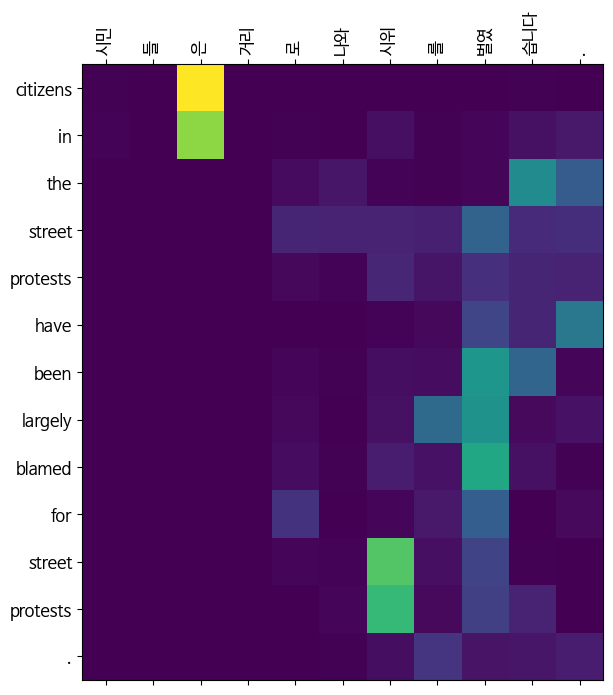

In [48]:
# 대표 문장 1개에 대해 심층 정성적 평가 진행
translation, tokens, attention_map = translate_sentence(test_pairs[0][0], model, ko_vocab, en_vocab)

print(f"Input: {test_pairs[0][0]}")
print(f"Predicted translation: {translation}")

# Attention Map 시각화
attention_map_clipped = attention_map[:len(translation.split()), :len(tokens)]
plot_attention(attention_map_clipped, tokens, translation.split())

In [49]:
analysis = analyze_translation_errors(candidates, references)
print_error_report(test_pairs, candidates, references, analysis)


      번역 오류 분석 리포트 (Error Analysis)

[문장 1]
  - 원문(KO): 시민들은 거리로 나와 시위를 벌였습니다.
  - 예측(EN): citizens in the street protests have been largely blamed for street protests .
  - 정답(EN): citizens took to the streets to protest .
  - 누락(Omission) 의심: ['to', 'took', 'streets', 'protest']
  -환각(Hallucination) 의심: ['largely', 'blamed', 'been', 'protests', 'have', 'street', 'for', 'in']
  - 단어 일치도: 42.9%
------------------------------

[문장 2]
  - 원문(KO): 나는 오늘 친구와 학식을 같이 먹었다.
  - 예측(EN): i m eating up with i m <unk> .
  - 정답(EN): i ate school meals with my friend today .
  - 누락(Omission) 의심: ['school', 'ate', 'friend', 'today', 'meals', 'my']
  -환각(Hallucination) 의심: ['eating', 'up', 'm', '<unk>']
  - 단어 일치도: 33.3%
------------------------------

[문장 3]
  - 원문(KO): 지금 매우 졸리고 힘들기 때문에 잠을 자야겠다.
  - 예측(EN): it s very difficult , she s often been so it s time for her .
  - 정답(EN): i need to sleep because i am very sleepy and tired now .
  - 누락(Omission) 의심: ['am', 'need', 'now', 'because', 'and', 's

### 추가 테스트

### 모델 추론 테스트 문장 구성 (Test Pairs_V2)
모델의 다양한 번역 성능을 정성적으로 평가하기 위해 총 10개의 문장 쌍을 구성했습니다.

1. **극도로 짧은 일상어:** 관용적 뉘앙스 파악 및 직역 방지 능력 평가
2. **이상치 대화 (초현실주의):** 상식 밖의 단어 조합 및 문맥 단절 상황에서의 번역 능력 평가
3. **장문 (약 30단어의 복문):** 긴 문장에서의 장기 의존성(Long-term dependency) 및 문장 구조 유지 능력 평가
4. **일반화 성능 1 (문어체):** 격식 있는 비즈니스/논리적 문장에 대한 번역 품질 확인
5. **일반화 성능 2 (구어체):** 일상적인 대화체에서의 자연스러운 의도 전달 확인
6. **인터넷 용어 1:** 신조어 처리 능력 (억까, 폼 미쳤다)
7. **인터넷 용어 2:** 신조어 처리 능력 (킹받네, 덕질)
8. **인터넷 용어 3:** 신조어 처리 능력 (뇌절, 갑분싸)
9. **인터넷 용어 4:** 신조어 처리 능력 (중꺾마, 존버, 떡상)
10. **인터넷 용어 5:** 신조어 처리 능력 (ㄹㅇ, 레전드, 웃참, 방종)

In [51]:
test_pairs_v2 = [
    ("그건 좀 선 넘었지.", "That crossed the line a bit."),
    ("냉장고가 너무 시끄러워서 내일은 보라색 양말을 신고 출근할 생각이야.", "The refrigerator is too loud, so I'm thinking of wearing purple socks to work tomorrow."),
    ("오늘 아침 출근길에 갑자기 굵은 비가 마구 쏟아지는 바람에 우산을 새로 사려고 근처 편의점에 들렀지만, 이미 내 앞서 들어온 사람들이 우산을 전부 사가는 바람에 결국 비를 흠뻑 맞고 젖은 채로 회사에 도착할 수밖에 없었다.",\
      "Because it suddenly started pouring heavily on my way to work this morning, I stopped by a nearby convenience store to buy a new umbrella, but the people who went in before me had already bought them all, so I had no choice but to arrive at the office completely drenched in rain."),
    ("새로운 기술을 도입하는 것은 초기 비용이 발생하지만, 장기적인 관점에서 보면 업무 효율성과 생산성을 크게 향상시킬 수 있습니다.", "Introducing new technology incurs initial costs, but from a long-term perspective, it can significantly improve work efficiency and productivity."),
    ("이번 주말에는 날씨가 맑을 거라고 하니, 오랜만에 가족들과 함께 복잡한 도심을 벗어나 근교로 드라이브나 다녀올까 고민 중이에요.", "They say the weather will be clear this weekend, so I'm thinking about going for a drive to the suburbs with my family for the first time in a while to get away from the crowded city."),
    ("이번 패치 완전 폼 미쳤다, 솔직히 이건 아무리 까칠한 유저라도 억까할 수가 없음.", "This patch is absolutely insane, honestly even the pickiest users can't force criticism on this."),
    ("아니 내 최애캐 오늘 미모 레알 킹받네, 당장 각 잡고 덕질하러 간다.", "Wow, my favorite character's beauty is seriously driving me crazy today, I'm going to get serious and fangirl/fanboy right now."),
    ("뇌절 그만하고 적당히 해라, 눈치 없이 계속 그러면 진짜 갑분싸 된다.", "Stop crossing the line and know when to quit, if you keep being clueless like that it's going to totally kill the mood."),
    ("솔직히 처음엔 폭망할 줄 알았는데, 중꺾마 마인드로 끝까지 존버했더니 결국 이렇게 떡상하네 ㅋㅋ", "Honestly I thought it would fail miserably at first, but after holding on to the end with an unbreakable spirit, it finally went to the moon lol."),
    ("어제 라이브 방송 ㄹㅇ 레전드 찍었음, 방종할 때까지 계속 웃참하느라 배 찢어지는 줄 알았다.", "Yesterday's live stream was truly legendary, my stomach felt like it was tearing apart from trying not to laugh until the stream ended.")
]

### epoch 20

In [ ]:
save_dir= f"./checkpoints_ED{EMB_DIM}_HD{HID_DIM}"
model.load_state_dict(torch.load(f'{save_dir}/seq2seq_model_epoch_20.pt', map_location=device))
model.eval()

In [52]:
candidates = []
references = []

print("--- 번역 결과 생성 중 ---")
for ko, en in test_pairs_v2:
    pred, _, _ = translate_sentence(ko, model, ko_vocab, en_vocab)
    # 토큰화된 결과에서 <start>, <end> 등 불필요한 태그 정리
    pred_clean = pred.replace("<start>", "").replace("<end>", "").strip()
    
    candidates.append(pred_clean)
    references.append(en)
    print(f"원문: {ko}\n예측: {pred_clean}\n정답: {en}\n")

--- 번역 결과 생성 중 ---
원문: 그건 좀 선 넘었지.
예측: it s a little bit too over .
정답: That crossed the line a bit.

원문: 냉장고가 너무 시끄러워서 내일은 보라색 양말을 신고 출근할 생각이야.
예측: as a day , the tomorrow will be days , when the u . s .
정답: The refrigerator is too loud, so I'm thinking of wearing purple socks to work tomorrow.

원문: 오늘 아침 출근길에 갑자기 굵은 비가 마구 쏟아지는 바람에 우산을 새로 사려고 근처 편의점에 들렀지만, 이미 내 앞서 들어온 사람들이 우산을 전부 사가는 바람에 결국 비를 흠뻑 맞고 젖은 채로 회사에 도착할 수밖에 없었다.
예측: the rest of the car is that , there s no change that the shooting included people that are already over the people .
정답: Because it suddenly started pouring heavily on my way to work this morning, I stopped by a nearby convenience store to buy a new umbrella, but the people who went in before me had already bought them all, so I had no choice but to arrive at the office completely drenched in rain.

원문: 새로운 기술을 도입하는 것은 초기 비용이 발생하지만, 장기적인 관점에서 보면 업무 효율성과 생산성을 크게 향상시킬 수 있습니다.
예측: that s new , but it s the early mean that the new york times is really .
정답: Introduci

[gemini 직역&번역]  
![직역번역표](./img/img1.png)

1. 일반 문장 테스트 결과    
비교적 짧은 문장에서는 핵심 단어를 잡아내지만, 문장이 길어지면 뉴스를 창조(Hallucination)하는 경향이 있습니다.

2. 신조어 및 슬랭 테스트 결과  
학습 데이터에 없는 인터넷 용어가 입력되면 모델이 아는 단어가 없어 <unk>(Unknown) 토큰이 발생하거나 전혀 다른 사회 이슈로 치환합니다.



### 정량적 평가

In [53]:
# 1. BLEU Score 측정
smoothie = SmoothingFunction().method4
bleu_scores = []
for cand, ref in zip(candidates, references):
    score_b = sentence_bleu([ref.split()], cand.split(), smoothing_function=smoothie)
    bleu_scores.append(score_b)

print(f"\n[정량적 평가 결과]")
print(f"평균 BLEU Score: {np.mean(bleu_scores):.4f}")


[정량적 평가 결과]
평균 BLEU Score: 0.0126


In [54]:
# 2. BERTScore 측정 (GPU VRAM 여유가 있을 때 실행)
try:
    print("\nBERTScore 계산 중 (잠시만 기다려주세요)...")
    P, R, F1 = score(candidates, references, lang="ko", verbose=False)
    print(f"평균 BERTScore (F1): {F1.mean().item():.4f}")
except Exception as e:
    print(f"BERTScore 계산 실패 (VRAM 부족 등): {e}")


BERTScore 계산 중 (잠시만 기다려주세요)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


평균 BERTScore (F1): 0.6491


### 정성적 평가

Input: 그건 좀 선 넘었지.
Predicted translation: it s a little bit too over .


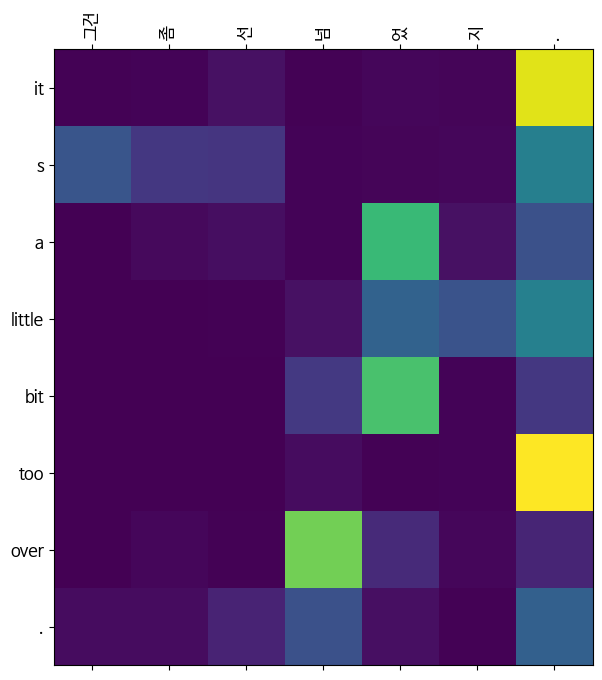

In [55]:
# 대표 문장 1개에 대해 심층 정성적 평가 진행
translation, tokens, attention_map = translate_sentence(test_pairs_v2[0][0], model, ko_vocab, en_vocab)

print(f"Input: {test_pairs_v2[0][0]}")
print(f"Predicted translation: {translation}")

# Attention Map 시각화
attention_map_clipped = attention_map[:len(translation.split()), :len(tokens)]
plot_attention(attention_map_clipped, tokens, translation.split())

In [56]:
analysis = analyze_translation_errors(candidates, references)
print_error_report(test_pairs_v2, candidates, references, analysis)


      번역 오류 분석 리포트 (Error Analysis)

[문장 1]
  - 원문(KO): 그건 좀 선 넘었지.
  - 예측(EN): it s a little bit too over .
  - 정답(EN): That crossed the line a bit.
  - 누락(Omission) 의심: ['bit.', 'line', 'the', 'that', 'crossed']
  -환각(Hallucination) 의심: ['it', 'bit', 's', 'over', '.', 'too', 'little']
  - 단어 일치도: 16.7%
------------------------------

[문장 2]
  - 원문(KO): 냉장고가 너무 시끄러워서 내일은 보라색 양말을 신고 출근할 생각이야.
  - 예측(EN): as a day , the tomorrow will be days , when the u . s .
  - 정답(EN): The refrigerator is too loud, so I'm thinking of wearing purple socks to work tomorrow.
  - 누락(Omission) 의심: ['is', 'so', 'work', 'purple', 'loud,', 'of', "i'm", 'thinking', 'socks', 'wearing', 'tomorrow.', 'refrigerator', 'to', 'too']
  -환각(Hallucination) 의심: ['tomorrow', 'will', 'days', 'day', 'u', 'as', 's', 'when', '.', 'be', ',', 'a']
  - 단어 일치도: 6.7%
------------------------------

[문장 3]
  - 원문(KO): 오늘 아침 출근길에 갑자기 굵은 비가 마구 쏟아지는 바람에 우산을 새로 사려고 근처 편의점에 들렀지만, 이미 내 앞서 들어온 사람들이 우산을 전부 사가는 바람에 결국 비를 흠뻑 맞고 젖은 채로 회사에 도

### epoch 30

In [ ]:
save_dir= f"./checkpoints_ED{EMB_DIM}_HD{HID_DIM}"
model.load_state_dict(torch.load(f'{save_dir}/seq2seq_model_epoch_30.pt', map_location=device))
model.eval()

In [59]:
candidates = []
references = []

print("--- 번역 결과 생성 중 ---")
for ko, en in test_pairs_v2:
    pred, _, _ = translate_sentence(ko, model, ko_vocab, en_vocab)
    # 토큰화된 결과에서 <start>, <end> 등 불필요한 태그 정리
    pred_clean = pred.replace("<start>", "").replace("<end>", "").strip()
    
    candidates.append(pred_clean)
    references.append(en)
    print(f"원문: {ko}\n예측: {pred_clean}\n정답: {en}\n")

--- 번역 결과 생성 중 ---
원문: 그건 좀 선 넘었지.
예측: it s the first time ever had a series of <unk> to the white .
정답: That crossed the line a bit.

원문: 냉장고가 너무 시끄러워서 내일은 보라색 양말을 신고 출근할 생각이야.
예측: when tomorrow is that , the government will continue its daily moment , and its impact will be made when tomorrow .
정답: The refrigerator is too loud, so I'm thinking of wearing purple socks to work tomorrow.

원문: 오늘 아침 출근길에 갑자기 굵은 비가 마구 쏟아지는 바람에 우산을 새로 사려고 근처 편의점에 들렀지만, 이미 내 앞서 들어온 사람들이 우산을 전부 사가는 바람에 결국 비를 흠뻑 맞고 젖은 채로 회사에 도착할 수밖에 없었다.
예측: the near owner of the president is set to open inside the wind as early morning but two shows people over the <unk> that the communist party s highest daily air .
정답: Because it suddenly started pouring heavily on my way to work this morning, I stopped by a nearby convenience store to buy a new umbrella, but the people who went in before me had already bought them all, so I had no choice but to arrive at the office completely drenched in rain.

원문: 새로운 기술을 도입하는 것은 초기 비용이 

[gemini 직역&번역]  
![직역번역표](./img/img2.png)

1. 일반 문장 테스트 결과    
문장이 길어질수록 모델이 아는 뉴스 패턴(대통령, 정부 등)을 억지로 끼워 맞추는 '환각(Hallucination)' 현상이 심해집니다.

2. 신조어 및 슬랭 테스트 결과  
인터넷 용어는 모델에게 '완전한 미지의 영역'입니다. '최애캐'를 '투데이 쇼'로, '떡상'을 '호주 군대'로 번역하는 등 도메인 불일치가 극명하게 나타납니다.



### 정량적 평가

In [60]:
# 1. BLEU Score 측정
smoothie = SmoothingFunction().method4
bleu_scores = []
for cand, ref in zip(candidates, references):
    score_b = sentence_bleu([ref.split()], cand.split(), smoothing_function=smoothie)
    bleu_scores.append(score_b)

print(f"\n[정량적 평가 결과]")
print(f"평균 BLEU Score: {np.mean(bleu_scores):.4f}")


[정량적 평가 결과]
평균 BLEU Score: 0.0120


In [61]:
# 2. BERTScore 측정 (GPU VRAM 여유가 있을 때 실행)
try:
    print("\nBERTScore 계산 중 (잠시만 기다려주세요)...")
    P, R, F1 = score(candidates, references, lang="ko", verbose=False)
    print(f"평균 BERTScore (F1): {F1.mean().item():.4f}")
except Exception as e:
    print(f"BERTScore 계산 실패 (VRAM 부족 등): {e}")


BERTScore 계산 중 (잠시만 기다려주세요)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


평균 BERTScore (F1): 0.6516


### 정성적 평가

Input: 그건 좀 선 넘었지.
Predicted translation: it s the first time ever had a series of <unk> to the white .


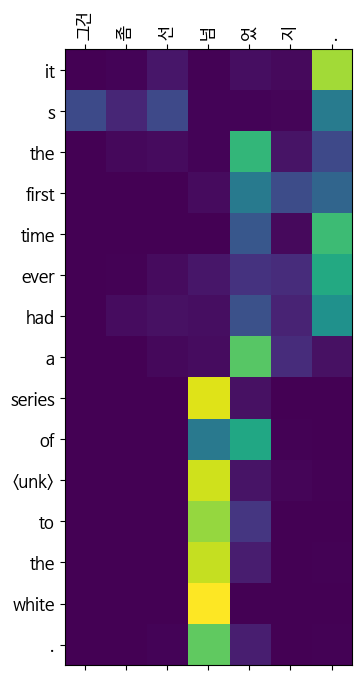

In [62]:
# 대표 문장 1개에 대해 심층 정성적 평가 진행
translation, tokens, attention_map = translate_sentence(test_pairs_v2[0][0], model, ko_vocab, en_vocab)

print(f"Input: {test_pairs_v2[0][0]}")
print(f"Predicted translation: {translation}")

# Attention Map 시각화
attention_map_clipped = attention_map[:len(translation.split()), :len(tokens)]
plot_attention(attention_map_clipped, tokens, translation.split())

In [63]:
analysis = analyze_translation_errors(candidates, references)
print_error_report(test_pairs_v2, candidates, references, analysis)


      번역 오류 분석 리포트 (Error Analysis)

[문장 1]
  - 원문(KO): 그건 좀 선 넘었지.
  - 예측(EN): it s the first time ever had a series of <unk> to the white .
  - 정답(EN): That crossed the line a bit.
  - 누락(Omission) 의심: ['crossed', 'bit.', 'line', 'that']
  -환각(Hallucination) 의심: ['had', 'it', 'first', 'series', 'of', 's', 'ever', 'time', '<unk>', 'white', '.', 'to']
  - 단어 일치도: 33.3%
------------------------------

[문장 2]
  - 원문(KO): 냉장고가 너무 시끄러워서 내일은 보라색 양말을 신고 출근할 생각이야.
  - 예측(EN): when tomorrow is that , the government will continue its daily moment , and its impact will be made when tomorrow .
  - 정답(EN): The refrigerator is too loud, so I'm thinking of wearing purple socks to work tomorrow.
  - 누락(Omission) 의심: ['so', 'work', 'purple', 'loud,', 'of', "i'm", 'thinking', 'socks', 'wearing', 'tomorrow.', 'refrigerator', 'to', 'too']
  -환각(Hallucination) 의심: ['tomorrow', 'will', 'its', ',', 'and', 'when', 'continue', 'made', 'impact', 'daily', 'moment', 'that', 'be', '.', 'government']
  - 단어 일치도: 